7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy without Dropout: 0.925
Accuracy with Dropout: 0.855


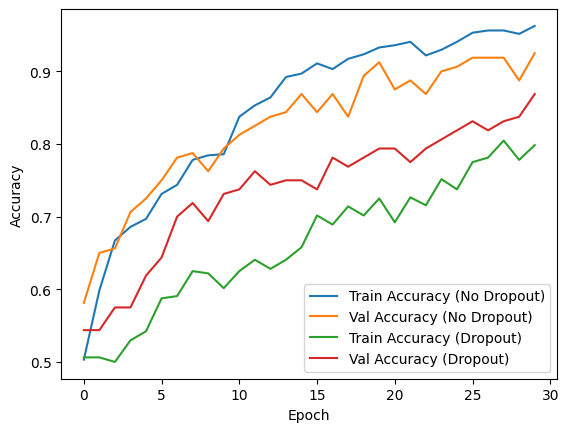

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.rand(1000, 10)
y = (X.sum(axis=1) > 5).astype(int)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
input_dim = X.shape[1]
model_no_dropout = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_no_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=30, batch_size=32,
                                          validation_split=0.2, verbose=0)

model_dropout = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_dropout = model_dropout.fit(X_train, y_train, epochs=30, batch_size=32,
                                    validation_split=0.2, verbose=0)

y_pred_no_dropout = (model_no_dropout.predict(X_test) > 0.5).astype(int)
y_pred_dropout = (model_dropout.predict(X_test) > 0.5).astype(int)

acc_no_dropout = accuracy_score(y_test, y_pred_no_dropout)
acc_dropout = accuracy_score(y_test, y_pred_dropout)

print("Accuracy without Dropout:", round(acc_no_dropout, 3))
print("Accuracy with Dropout:", round(acc_dropout, 3))

plt.plot(history_no_dropout.history['accuracy'], label='Train Accuracy (No Dropout)')
plt.plot(history_no_dropout.history['val_accuracy'], label='Val Accuracy (No Dropout)')
plt.plot(history_dropout.history['accuracy'], label='Train Accuracy (Dropout)')
plt.plot(history_dropout.history['val_accuracy'], label='Val Accuracy (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
